# Información y Programación Financiera, TI, Algoritmos y Ciencia de Datos

Neftalí Valdez

<a href="http://twitter.com/neftalivldz" target="_blank">@neftalivldz</a> | <a href="mailto:nvaldez@tec.mx">nvaldez@tec.mx</a>

In [27]:
#%pip install TA-Lib


In [1]:
from stock_price_downloader import StockPriceDownloader

import talib as ta
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Crear instancia
df = StockPriceDownloader('AAPL', '2022-01-01')
# Descargar datos
df = df.download_data()

df

[*********************100%***********************]  1 of 1 completed

Successfully downloaded 1038 records


,close,high,low,open,volume
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400
2022-01-05,171.165848,176.303172,170.891858,175.755193,94537600
2022-01-06,168.308533,171.537711,167.956258,168.993506,96904000
2022-01-07,168.474838,170.402559,167.359306,169.179387,86709100
...,...,...,...,...,...
2026-02-17,263.880005,266.290009,255.539993,258.049988,58469100
2026-02-18,264.350006,266.820007,262.450012,263.600006,34203300
2026-02-19,260.579987,264.480011,260.049988,262.600006,30845300


In [3]:
df['close']

Date
2022-01-03    178.103668
2022-01-04    175.843231
2022-01-05    171.165848
2022-01-06    168.308533
2022-01-07    168.474838
                 ...    
2026-02-17    263.880005
2026-02-18    264.350006
2026-02-19    260.579987
2026-02-20    264.579987
2026-02-23    266.179993
Name: close, Length: 1038, dtype: float64

In [4]:
for t in [5, 21, 63]:
    print(t)

5
21
63


In [5]:
plt.style.use('tableau-colorblind10')
%config InlineBackend.figure_format = 'svg'

In [6]:
df['close']

Date
2022-01-03    178.103668
2022-01-04    175.843231
2022-01-05    171.165848
2022-01-06    168.308533
2022-01-07    168.474838
                 ...    
2026-02-17    263.880005
2026-02-18    264.350006
2026-02-19    260.579987
2026-02-20    264.579987
2026-02-23    266.179993
Name: close, Length: 1038, dtype: float64

In [ ]:
for t in [5, 21, 63]:
    df[f'EMA_{t}'] = ta.EMA(df['close'],
                               timeperiod=t)


In [ ]:
# Plotting
plt.figure(figsize=(12, 6))

# Plot Closing Price and EMAs
plt.plot(df['close'], label='Close Price', alpha=0.5)
plt.plot(df['EMA_21'], label='21-Day EMA', alpha=0.75, color='blue')
plt.plot(df['EMA_63'], label='63-Day EMA', alpha=0.75, color='orange')

plt.title('Price with EMA')
plt.legend()
plt.show()


In [ ]:
# Generate Buy and Sell signals (EMA crossover)
df['Buy_Signal']  = (df['EMA_21'] >  df['EMA_63']) & (df['EMA_21'].shift(1) <= df['EMA_63'].shift(1))
df['Buy_Signal']  = df['Buy_Signal'].astype(int)
df['Sell_Signal'] = (df['EMA_21'] <  df['EMA_63']) & (df['EMA_21'].shift(1) >= df['EMA_63'].shift(1))
df['Sell_Signal'] = df['Sell_Signal'].map({True: -1, False: 0})

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(df['close'],  label='Close Price', alpha=0.5)
plt.plot(df['EMA_21'], label='21-Day EMA',  alpha=0.75, color='blue')
plt.plot(df['EMA_63'], label='63-Day EMA',  alpha=0.75, color='orange')

buys  = df[df['Buy_Signal']  == 1]
sells = df[df['Sell_Signal'] == -1]
plt.plot(buys.index,  df.loc[buys.index,  'close'], '^', markersize=10, color='g', lw=0, label='Buy Signal')
plt.plot(sells.index, df.loc[sells.index, 'close'], 'v', markersize=10, color='r', lw=0, label='Sell Signal')

plt.title('Price with EMA Crossover Buy and Sell Signals')
plt.legend()
plt.show()


In [ ]:
df['position'] = (df['EMA_21'] > df['EMA_63']).map({True: 1, False: -1})


In [ ]:
from matplotlib.dates import AutoDateFormatter, AutoDateLocator

fig, ax1 = plt.subplots(figsize=(12, 6))
l1, = ax1.plot(df.index, df['close'], label='Close Price', alpha=0.5)
ax1.set_ylabel('Price (y1 axis)')
ax1.plot(df['EMA_21'], label='21-Day EMA', alpha=0.75, color='blue')
ax1.plot(df['EMA_63'], label='63-Day EMA', alpha=0.75, color='orange')

buys  = df[df['Buy_Signal']  == 1]
sells = df[df['Sell_Signal'] == -1]
ax1.plot(buys.index,  df.loc[buys.index,  'close'], '^', markersize=10, color='g', lw=0, label='Buy Signal')
ax1.plot(sells.index, df.loc[sells.index, 'close'], 'v', markersize=10, color='r', lw=0, label='Sell Signal')

ax2 = ax1.twinx()
l2, = ax2.plot(df.index, df['position'], alpha=0.75, color='pink')
ax2.set_ylabel('Position')

fig.legend([l1, l2], ['Price', 'Position'])

xtick_locator   = AutoDateLocator()
xtick_formatter = AutoDateFormatter(xtick_locator)
ax1.xaxis.set_major_locator(xtick_locator)
ax1.xaxis.set_major_formatter(xtick_formatter)


In [12]:
df['Returns'] = np.log(df['close'] / df['close'].shift(1))
df['Strategy'] = df['position'].shift(1) * df['Returns']  
df.round(4).head()
df = df.dropna(how='all')

In [13]:
df.dropna(inplace=True)


In [14]:
np.exp(df[['Returns', 'Strategy']].sum())  


Returns     1.555878
Strategy    1.471625
dtype: float64

In [15]:
df[['Returns', 'Strategy']].std() * 252 ** 0.5


Returns     0.282780
Strategy    0.282802
dtype: float64

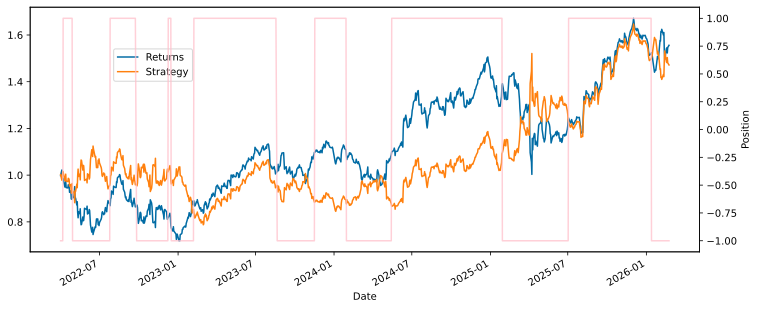

In [16]:
ax1 = df[['Returns', 'Strategy']].cumsum(
        ).apply(np.exp).plot(figsize=(12,5))

ax2 = ax1.twinx() ##Using twinx to make ax2 as secondary axis for ax1
l2, = ax2.plot(df.index,df['position'], alpha=0.75, color='pink') #Your sales field
ax2.set_ylabel('Position')

fig.legend([l1, l2], ["Price", "Position"])

xtick_locator = AutoDateLocator()
xtick_formatter = AutoDateFormatter(xtick_locator)

ax1.xaxis.set_major_locator(xtick_locator)
ax1.xaxis.set_major_formatter(xtick_formatter)

ax1.get_legend().set_bbox_to_anchor((0.25, 0.85));
# plt.savefig('../../images/ch15/strat_plot_03.png');